## رگرسیون خطی ساده

In [101]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import sklearn

ModuleNotFoundError: No module named 'sklearn'

In [4]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [11]:
df["MODELYEAR"].head()

0    2014
1    2014
2    2014
3    2014
4    2014
Name: MODELYEAR, dtype: int64

In [20]:
df["ENGINESIZE"].head(5)

0    2.0
1    2.4
2    1.5
3    3.5
4    3.5
Name: ENGINESIZE, dtype: float64

In [21]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


### به این شکل دیتا هایی که خواستیم و یه مقدار محدو تر کردیم. با این روش میتونیم دیتاهایی که میخوایم باهاشون کار کنیم رو جدا کنیم که راحت تر باشیم

In [50]:
my_df = df[["ENGINESIZE" , "CYLINDERS" , "FUELCONSUMPTION_CITY" , "CO2EMISSIONS" , "FUELCONSUMPTION_COMB"]]
my_df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,CO2EMISSIONS,FUELCONSUMPTION_COMB
0,2.0,4,9.9,196,8.5
1,2.4,4,11.2,221,9.6
2,1.5,4,6.0,136,5.9
3,3.5,6,12.7,255,11.1
4,3.5,6,12.1,244,10.6


In [33]:
df[["ENGINESIZE"]].head()

,ENGINESIZE
0,2.0
1,2.4
2,1.5
3,3.5
4,3.5


In [35]:
df["ENGINESIZE"].head()

0    2.0
1    2.4
2    1.5
3    3.5
4    3.5
Name: ENGINESIZE, dtype: float64

### با استفاده کردن از هیستوگرام میشه فهمید از هر کدوم از دیتاهایی که داریم چند تا هست اینطوری یه نمای کلی از دیتاهامون بدست میاریم

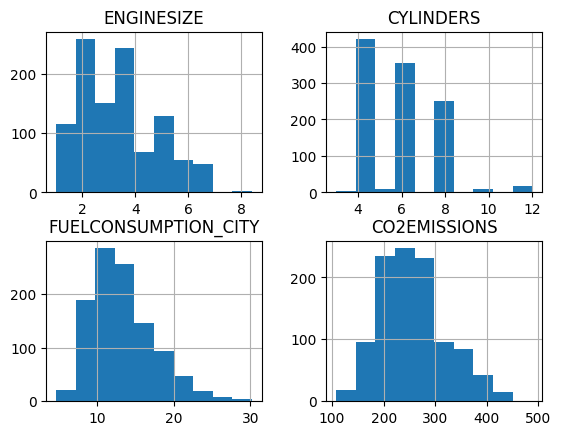

In [40]:
my_df.hist()
plt.show()

## گام او در دیتا ساینس شناخت دیتا است. دیتاساینتیست در گام اول باید دیتای خودش را بشناسد

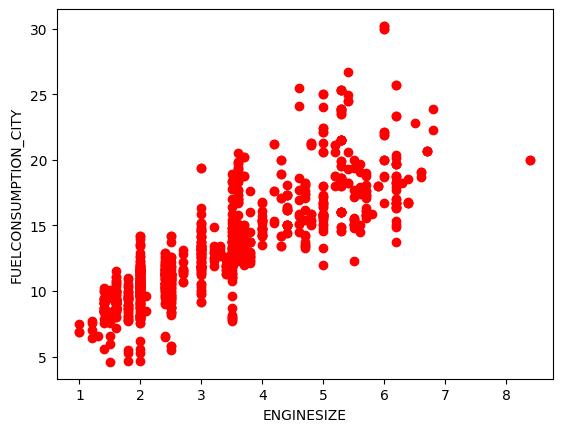

In [45]:
plt.scatter(my_df.ENGINESIZE , my_df.FUELCONSUMPTION_CITY , color = "red")
plt.xlabel("ENGINESIZE")
plt.ylabel("FUELCONSUMPTION_CITY")
plt.show()

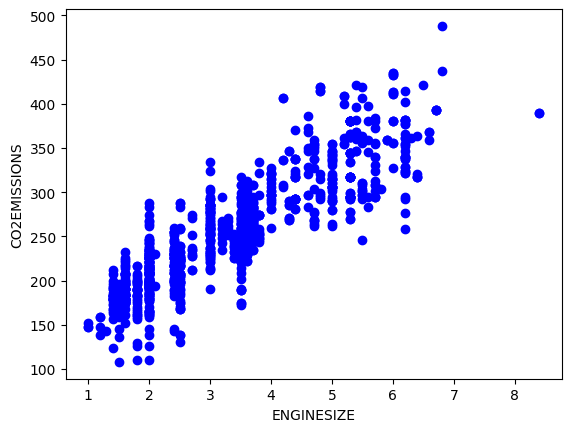

In [49]:
plt.scatter(my_df.ENGINESIZE , my_df.CO2EMISSIONS , color = "blue")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

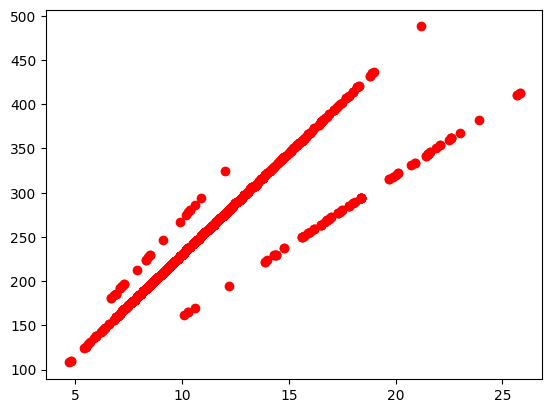

In [52]:
plt.scatter(my_df.FUELCONSUMPTION_COMB , my_df.CO2EMISSIONS , color = "red")
plt.show()

In [53]:
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


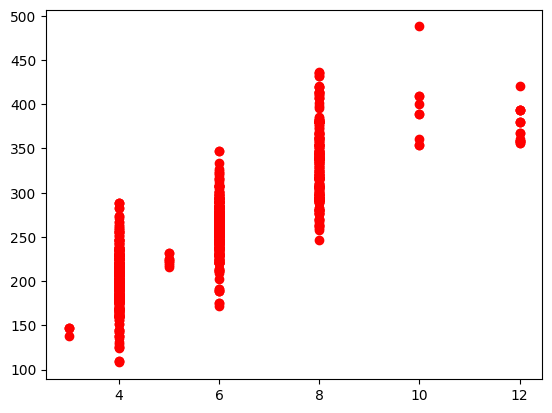

In [54]:
plt.scatter(df.CYLINDERS , df.CO2EMISSIONS , color = "red")
plt.show()

In [96]:
msk = np.random.rand(len(df)) < 0.8
msk

array([False, False,  True, ...,  True,  True, False], shape=(1067,))

### در اینجا ماسک ما میشه حدودا 80 درصد true

In [97]:
train = df[msk]
test = df[~msk]


In [85]:
train

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [86]:
test

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
13,2014,ASTON MARTIN,RAPIDE,SUBCOMPACT,5.9,12,A6,Z,18.0,12.6,15.6,18,359
14,2014,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338
15,2014,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,M6,Z,18.1,12.2,15.4,18,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,2014,VOLKSWAGEN,BEETLE,COMPACT,1.8,4,A6,X,9.5,7.2,8.5,33,196
1032,2014,VOLKSWAGEN,GOLF WAGON TDI CLEAN DIESEL,STATION WAGON - SMALL,2.0,4,A6,D,8.2,6.0,7.2,39,194
1035,2014,VOLKSWAGEN,JETTA,COMPACT,1.8,4,M5,X,9.4,6.7,8.2,34,189
1040,2014,VOLKSWAGEN,JETTA TDI CLEAN DIESEL,COMPACT,2.0,4,A6,D,7.9,5.7,6.9,41,186


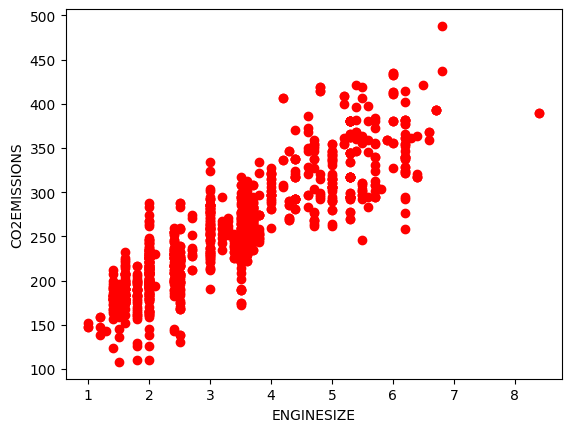

In [98]:
plt.scatter(df.ENGINESIZE , df.CO2EMISSIONS , color = "red")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

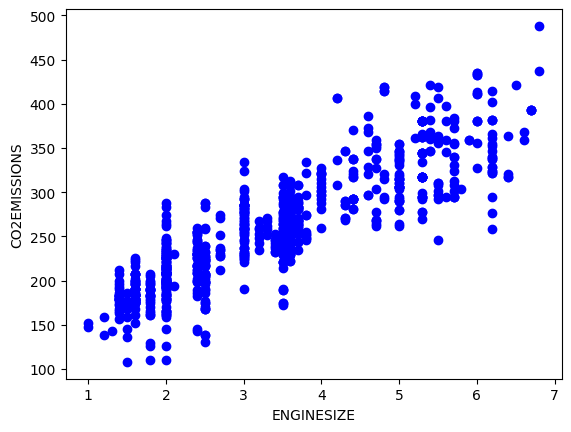

In [99]:
plt.scatter(train.ENGINESIZE , train.CO2EMISSIONS , color = "blue")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

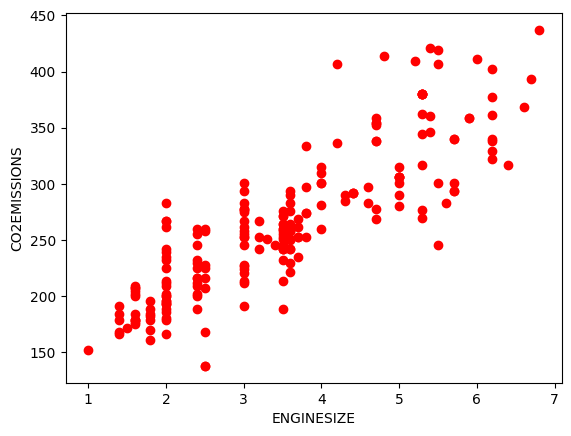

In [93]:
plt.scatter(test.ENGINESIZE , test.CO2EMISSIONS , color = "red")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

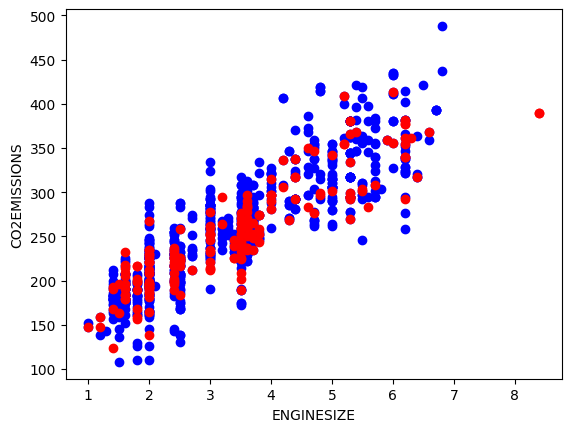

In [100]:
plt.scatter(train.ENGINESIZE , train.CO2EMISSIONS , color = "blue")
plt.scatter(test.ENGINESIZE , test.CO2EMISSIONS , color = "red")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()